# Prequential Evaluation of Surrogate Models — Function 1

**Goal**: Identify the best surrogate model and hyperparameters for the radiation source detection problem (F1) using one-step-ahead prequential evaluation.

| Property | Value |
|----------|-------|
| Input dimensions | 2 |
| Output dimensions | 1 |
| Objective | Maximise |
| Initial samples | 10 |
| Total samples (Week 6) | 16 |
| Evaluation steps | 6 (one-step-ahead predictions) |

**Methodology**: Train a surrogate on the first 10 data points, predict the 11th, record the error, retrain on 11 data points, predict the 12th, and so on. This is repeated for each surrogate model to compare predictive performance.

## Evaluation Metrics

Three metrics are used to assess surrogate quality:

1. **MAE (Mean Absolute Error)**: Average absolute difference between predicted and actual values. Less sensitive to outliers than RMSE.

2. **NLP (Negative Log Predictive Density)**: Measures how well the model's predicted distribution matches the actual observation. Lower is better. Penalises both poor mean predictions and poorly calibrated uncertainty.

   $$\text{NLP} = \frac{1}{2}\log(2\pi\sigma^2) + \frac{(y - \mu)^2}{2\sigma^2}$$

3. **Coverage of 95% Prediction Interval**: Fraction of actual values falling inside the model's 95% confidence interval. A well-calibrated model should achieve ~95% coverage.

In [1]:
import numpy as np
import torch
import matplotlib.pyplot as plt
import pandas as pd
import warnings
warnings.filterwarnings('ignore')

# BoTorch / GPyTorch for Gaussian Process
import gpytorch
from botorch.models import SingleTaskGP
from botorch.fit import fit_gpytorch_mll
from gpytorch.mlls import ExactMarginalLogLikelihood
from gpytorch.kernels import MaternKernel, RBFKernel, ScaleKernel
from gpytorch.constraints import GreaterThan
from gpytorch.likelihoods import GaussianLikelihood

# PyMC / BART
import pymc as pm
import pymc_bart as pmb

np.random.seed(42)
torch.manual_seed(42)

print('All libraries imported successfully.')

All libraries imported successfully.


## Step 1: Load Data

Set `WEEK` to choose which weekly snapshot to evaluate (default: 6). This loads all samples up to that week. The first 10 are the initial samples; the remaining are the sequentially acquired points.

In [2]:
# ── Configuration ───────────────────────────────────────────────
WEEK = 6          # Change this to evaluate a different weekly snapshot
# ────────────────────────────────────────────────────────────────

# Load data for the selected week (contains all samples up to that week)
X_all = np.load(f'../../data/f1/updated_inputs - Week {WEEK}.npy')
y_all = np.load(f'../../data/f1/updated_outputs - Week {WEEK}.npy')

# Initial training set size
N_INIT = 10

print(f'Week: {WEEK}')
print(f'Total samples: {X_all.shape[0]}')
print(f'Input dimensions: {X_all.shape[1]}')
print(f'Initial training set: {N_INIT} samples')
print(f'Evaluation steps: {X_all.shape[0] - N_INIT} one-step-ahead predictions')
print(f'\nOutput range: [{y_all.min():.6e}, {y_all.max():.6e}]')
print(f'Output mean: {y_all.mean():.6e}')
print(f'Output std: {y_all.std():.6e}')

# Display all samples
print('\nAll data points:')
for i in range(len(X_all)):
    marker = ' (initial)' if i < N_INIT else ' (sequential)'
    print(f'  [{i:2d}] X = [{X_all[i,0]:.6f}, {X_all[i,1]:.6f}]  y = {y_all[i]:+.6e}{marker}')

Week: 6
Total samples: 16
Input dimensions: 2
Initial training set: 10 samples
Evaluation steps: 6 one-step-ahead predictions

Output range: [-3.606063e-03, 7.710875e-16]
Output mean: -2.253789e-04
Output std: 8.728888e-04

All data points:
  [ 0] X = [0.319404, 0.762959]  y = +1.322677e-79 (initial)
  [ 1] X = [0.574329, 0.879898]  y = +1.033078e-46 (initial)
  [ 2] X = [0.731024, 0.733000]  y = +7.710875e-16 (initial)
  [ 3] X = [0.840353, 0.264732]  y = +3.341771e-124 (initial)
  [ 4] X = [0.650114, 0.681526]  y = -3.606063e-03 (initial)
  [ 5] X = [0.410437, 0.147554]  y = -2.159249e-54 (initial)
  [ 6] X = [0.312691, 0.078723]  y = -2.089093e-91 (initial)
  [ 7] X = [0.683418, 0.861057]  y = +2.535001e-40 (initial)
  [ 8] X = [0.082507, 0.403488]  y = +3.606771e-81 (initial)
  [ 9] X = [0.883890, 0.582254]  y = +6.229856e-48 (initial)
  [10] X = [0.448979, 0.142857]  y = +2.314081e-56 (sequential)
  [11] X = [0.708964, 0.494269]  y = -1.159884e-17 (sequential)
  [12] X = [0.986481

## Step 2: Define Evaluation Metrics

In [3]:
def compute_metrics(predictions, actuals, pred_means, pred_stds):
    """
    Compute prequential evaluation metrics.
    
    Parameters
    ----------
    predictions : list of float — point predictions (mean) for each step
    actuals     : list of float — actual observed values for each step
    pred_means  : list of float — predicted means (same as predictions)
    pred_stds   : list of float — predicted standard deviations (uncertainty)
    
    Returns
    -------
    dict with MAE, NLP, Coverage_95, and per-step details
    """
    predictions = np.array(predictions)
    actuals = np.array(actuals)
    pred_means = np.array(pred_means)
    pred_stds = np.array(pred_stds)
    
    # MAE
    mae = np.mean(np.abs(actuals - predictions))
    
    # Negative Log Predictive Density (NLP)
    # NLP_i = 0.5 * log(2*pi*sigma^2) + (y - mu)^2 / (2*sigma^2)
    stds_clipped = np.clip(pred_stds, 1e-10, None)
    nlp_values = 0.5 * np.log(2 * np.pi * stds_clipped**2) + \
                 (actuals - pred_means)**2 / (2 * stds_clipped**2)
    mean_nlp = np.mean(nlp_values)
    
    # 95% Prediction Interval Coverage
    lower = pred_means - 1.96 * stds_clipped
    upper = pred_means + 1.96 * stds_clipped
    in_interval = (actuals >= lower) & (actuals <= upper)
    coverage_95 = np.mean(in_interval)
    
    return {
        'MAE': mae,
        'NLP': mean_nlp,
        'Coverage_95': coverage_95,
        'nlp_values': nlp_values,
        'errors': actuals - predictions,
        'in_interval': in_interval
    }

print('Metric functions defined.')

Metric functions defined.


## Step 3: Gaussian Process — Prequential Evaluation

### Initial Hyperparameters

The GP uses BoTorch's `SingleTaskGP` with the following default configuration:
- **Kernel**: Matérn 5/2 with automatic relevance determination (ARD)
- **Mean function**: Constant mean
- **Noise**: Learned homoscedastic noise
- **Fitting**: Marginal likelihood maximisation (the Bayesian-correct approach for GPs — no cross-validation needed)

These are standard choices for radiation-field-like functions where smoothness is expected but the length scale is unknown.

In [4]:
def gp_prequential_evaluation(X_all, y_all, n_init):
    """
    Perform one-step-ahead prequential evaluation using a Gaussian Process.
    
    Parameters
    ----------
    X_all  : np.ndarray, shape (N, D) - all input data
    y_all  : np.ndarray, shape (N,)   - all output data
    n_init : int                       - number of initial training points
    
    Returns
    -------
    dict with predictions, actuals, metrics, and model details
    """
    n_total = len(y_all)
    n_steps = n_total - n_init
    
    predictions = []
    actuals = []
    pred_means = []
    pred_stds = []
    
    print(f'Running GP (Matern 5/2) prequential evaluation...')
    print(f'  Training starts with {n_init} points, evaluating {n_steps} steps\\n')
    
    for step in range(n_steps):
        # Current training set
        n_train = n_init + step
        X_train = torch.tensor(X_all[:n_train], dtype=torch.float64)
        y_train = torch.tensor(y_all[:n_train], dtype=torch.float64).unsqueeze(-1)
        
        # Test point (next observation)
        X_test = torch.tensor(X_all[n_train:n_train+1], dtype=torch.float64)
        y_actual = y_all[n_train]
        
        # Build and fit GP model
        model = SingleTaskGP(X_train, y_train)
        mll = ExactMarginalLogLikelihood(model.likelihood, model)
        fit_gpytorch_mll(mll)
        
        # Predict
        model.eval()
        with torch.no_grad():
            posterior = model.posterior(X_test)
            mean = posterior.mean.item()
            std = posterior.variance.sqrt().item()
        
        predictions.append(mean)
        actuals.append(y_actual)
        pred_means.append(mean)
        pred_stds.append(std)
        
        print(f'  Step {step+1}: train={n_train} pts | '
              f'predicted={mean:+.6e} | actual={y_actual:+.6e} | '
              f'error={y_actual - mean:+.6e} | std={std:.6e}')
    
    # Compute metrics
    metrics = compute_metrics(predictions, actuals, pred_means, pred_stds)
    
    print(f'\\n  Results:')
    print(f'    MAE:          {metrics["MAE"]:.6e}')
    print(f'    Mean NLP:     {metrics["NLP"]:.4f}')
    print(f'    95%% Coverage: {metrics["Coverage_95"]:.1%}')
    
    return {
        'predictions': predictions,
        'actuals': actuals,
        'pred_means': pred_means,
        'pred_stds': pred_stds,
        'metrics': metrics
    }

print('GP prequential function defined.')

GP prequential function defined.


### Run GP with Default Hyperparameters

In [5]:
gp_default_results = gp_prequential_evaluation(X_all, y_all, N_INIT)

Running GP (Matern 5/2) prequential evaluation...
  Training starts with 10 points, evaluating 6 steps\n
  Step 1: train=10 pts | predicted=-1.263406e-04 | actual=+2.314081e-56 | error=+1.263406e-04 | std=8.809365e-04
  Step 2: train=11 pts | predicted=-3.858174e-04 | actual=-1.159884e-17 | error=+3.858174e-04 | std=1.087101e-03
  Step 3: train=12 pts | predicted=-3.526792e-04 | actual=+4.977703e-180 | error=+3.526792e-04 | std=1.040978e-03
  Step 4: train=13 pts | predicted=-2.892823e-04 | actual=+2.842720e-97 | error=+2.892823e-04 | std=9.978035e-04
  Step 5: train=14 pts | predicted=-1.175092e-04 | actual=+1.018730e-40 | error=+1.175092e-04 | std=5.335006e-04
  Step 6: train=15 pts | predicted=-2.084423e-04 | actual=+0.000000e+00 | error=+2.084423e-04 | std=8.985372e-04
\n  Results:
    MAE:          2.466785e-04
    Mean NLP:     -6.0749
    95%% Coverage: 100.0%


### GP Default Results — Visualisation

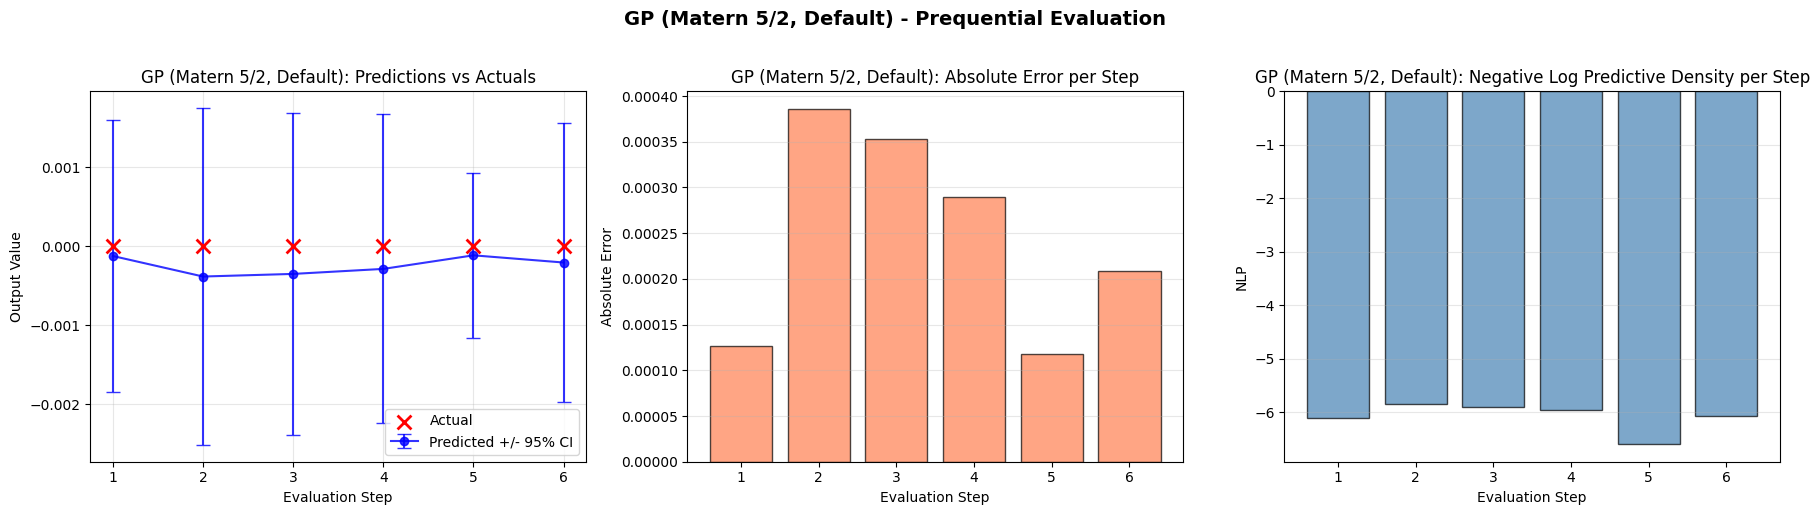

In [6]:
def plot_prequential_results(results, model_name):
    """Plot prequential evaluation results for a single model."""
    actuals = np.array(results['actuals'])
    preds = np.array(results['pred_means'])
    stds = np.array(results['pred_stds'])
    steps = np.arange(1, len(actuals) + 1)
    
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    
    # Plot 1: Predictions vs Actuals with uncertainty
    ax = axes[0]
    ax.errorbar(steps, preds, yerr=1.96*stds, fmt='o-', color='blue',
                capsize=5, label='Predicted +/- 95% CI', alpha=0.8)
    ax.scatter(steps, actuals, color='red', s=100, zorder=5,
               marker='x', linewidths=2, label='Actual')
    ax.set_xlabel('Evaluation Step')
    ax.set_ylabel('Output Value')
    ax.set_title(f'{model_name}: Predictions vs Actuals')
    ax.legend()
    ax.grid(True, alpha=0.3)
    
    # Plot 2: Absolute errors
    ax = axes[1]
    errors = np.abs(actuals - preds)
    ax.bar(steps, errors, color='coral', edgecolor='black', alpha=0.7)
    ax.set_xlabel('Evaluation Step')
    ax.set_ylabel('Absolute Error')
    ax.set_title(f'{model_name}: Absolute Error per Step')
    ax.grid(True, alpha=0.3, axis='y')
    
    # Plot 3: NLP per step
    ax = axes[2]
    nlp_vals = results['metrics']['nlp_values']
    ax.bar(steps, nlp_vals, color='steelblue', edgecolor='black', alpha=0.7)
    ax.set_xlabel('Evaluation Step')
    ax.set_ylabel('NLP')
    ax.set_title(f'{model_name}: Negative Log Predictive Density per Step')
    ax.grid(True, alpha=0.3, axis='y')
    
    plt.suptitle(f'{model_name} - Prequential Evaluation', fontsize=14, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.show()

plot_prequential_results(gp_default_results, 'GP (Matern 5/2, Default)')

### GP Hyperparameter Optimisation (10 Iterations)

We optimise the GP configuration by trying different kernel and noise settings.
At each iteration we evaluate the full prequential loop and record the aggregate metrics.

**Hyperparameters varied:**
- **Kernel**: Matérn 5/2 vs RBF (Squared Exponential)
- **Output warping**: Whether to apply a log-transform to outputs (useful when values span many orders of magnitude)
- **Noise constraint**: Lower bound on the noise parameter

The GP length-scale and output-scale are always optimised via marginal likelihood — this is the Bayesian-correct approach and does not require cross-validation.

In [7]:
def gp_prequential_with_config(X_all, y_all, n_init, config):
    """
    Run GP prequential evaluation with a specific configuration.
    
    config dict keys:
        kernel_type   : 'matern' or 'rbf'
        log_transform : bool - apply log(|y|+eps) transform
        noise_lb      : float - lower bound for noise
    """
    EPS = 1e-300
    n_total = len(y_all)
    n_steps = n_total - n_init
    
    # Optionally transform outputs: z = log(|y| + eps)
    if config.get('log_transform', False):
        y_work = np.log(np.abs(y_all) + EPS)
    else:
        y_work = y_all.copy()
    
    predictions = []
    actuals_transformed = []
    pred_means = []
    pred_stds = []
    
    for step in range(n_steps):
        n_train = n_init + step
        X_train = torch.tensor(X_all[:n_train], dtype=torch.float64)
        y_train = torch.tensor(y_work[:n_train], dtype=torch.float64).unsqueeze(-1)
        
        X_test = torch.tensor(X_all[n_train:n_train+1], dtype=torch.float64)
        y_actual = y_work[n_train]
        
        # ── Build kernel based on config (T003) ──────────────────────
        d = X_train.shape[-1]
        if config.get('kernel_type', 'matern') == 'rbf':
            base_kernel = RBFKernel(ard_num_dims=d)
        else:
            base_kernel = MaternKernel(nu=2.5, ard_num_dims=d)
        covar_module = ScaleKernel(base_kernel)
        
        # ── Build likelihood with noise lower bound (T004) ───────────
        noise_lb = config.get('noise_lb', 1e-5)
        likelihood = GaussianLikelihood(noise_constraint=GreaterThan(noise_lb))
        
        # ── Build GP model ────────────────────────────────────────────
        model = SingleTaskGP(
            X_train, y_train,
            covar_module=covar_module,
            likelihood=likelihood,
        )
        mll = ExactMarginalLogLikelihood(model.likelihood, model)
        
        try:
            fit_gpytorch_mll(mll)
        except Exception:
            pass  # Use current hyperparameters if fitting fails
        
        model.eval()
        with torch.no_grad():
            posterior = model.posterior(X_test)
            mean = posterior.mean.item()
            std = posterior.variance.sqrt().item()
        
        predictions.append(mean)
        actuals_transformed.append(y_actual)
        pred_means.append(mean)
        pred_stds.append(std)
    
    # Report metrics in the space the model operates in
    metrics = compute_metrics(predictions, actuals_transformed, pred_means, pred_stds)
    
    # Also compute MAE in original space for interpretability (T005)
    if config.get('log_transform', False):
        # Inverse of log-transform: y = exp(z) - eps
        orig_preds = np.exp(np.array(predictions)) - EPS
        orig_preds = np.maximum(orig_preds, 0.0)  # Clip to non-negative
        orig_actuals = y_all[n_init:]
        metrics['MAE_original'] = np.mean(np.abs(orig_actuals - orig_preds))
    else:
        metrics['MAE_original'] = metrics['MAE']
    
    return metrics


# Define 10 hyperparameter configurations to try
hp_configs = [
    {'kernel_type': 'matern', 'log_transform': False, 'noise_lb': 1e-5,
     'label': 'Matern, raw, noise>=1e-5'},
    {'kernel_type': 'matern', 'log_transform': False, 'noise_lb': 1e-4,
     'label': 'Matern, raw, noise>=1e-4'},
    {'kernel_type': 'matern', 'log_transform': False, 'noise_lb': 1e-6,
     'label': 'Matern, raw, noise>=1e-6'},
    {'kernel_type': 'rbf', 'log_transform': False, 'noise_lb': 1e-5,
     'label': 'RBF, raw, noise>=1e-5'},
    {'kernel_type': 'rbf', 'log_transform': False, 'noise_lb': 1e-4,
     'label': 'RBF, raw, noise>=1e-4'},
    {'kernel_type': 'matern', 'log_transform': True, 'noise_lb': 1e-5,
     'label': 'Matern, log-transform, noise>=1e-5'},
    {'kernel_type': 'matern', 'log_transform': True, 'noise_lb': 1e-4,
     'label': 'Matern, log-transform, noise>=1e-4'},
    {'kernel_type': 'rbf', 'log_transform': True, 'noise_lb': 1e-5,
     'label': 'RBF, log-transform, noise>=1e-5'},
    {'kernel_type': 'rbf', 'log_transform': True, 'noise_lb': 1e-4,
     'label': 'RBF, log-transform, noise>=1e-4'},
    {'kernel_type': 'matern', 'log_transform': True, 'noise_lb': 1e-6,
     'label': 'Matern, log-transform, noise>=1e-6'},
]

print('Running GP hyperparameter optimisation (10 configurations)...')
print('=' * 80)

gp_hp_results = []
for i, config in enumerate(hp_configs):
    print(f'\nConfig {i+1}/10: {config["label"]}')
    try:
        metrics = gp_prequential_with_config(X_all, y_all, N_INIT, config)
        gp_hp_results.append({
            'config_id': i + 1,
            'label': config['label'],
            'MAE': metrics['MAE'],
            'MAE_original': metrics['MAE_original'],
            'NLP': metrics['NLP'],
            'Coverage_95': metrics['Coverage_95']
        })
        print(f'  MAE={metrics["MAE"]:.6e}  NLP={metrics["NLP"]:.4f}  '
              f'Coverage={metrics["Coverage_95"]:.1%}')
    except Exception as e:
        print(f'  FAILED: {e}')
        gp_hp_results.append({
            'config_id': i + 1,
            'label': config['label'],
            'MAE': np.nan, 'MAE_original': np.nan,
            'NLP': np.nan, 'Coverage_95': np.nan
        })

gp_hp_df = pd.DataFrame(gp_hp_results)
print('\n' + '=' * 80)
print('GP Hyperparameter Results:')
print(gp_hp_df.to_string(index=False))

Running GP hyperparameter optimisation (10 configurations)...

Config 1/10: Matern, raw, noise>=1e-5
  MAE=2.940508e-04  NLP=430.1497  Coverage=0.0%

Config 2/10: Matern, raw, noise>=1e-4
  MAE=2.940509e-04  NLP=430.1514  Coverage=0.0%

Config 3/10: Matern, raw, noise>=1e-6
  MAE=2.940531e-04  NLP=430.1579  Coverage=0.0%

Config 4/10: RBF, raw, noise>=1e-5
  MAE=2.940531e-04  NLP=430.1575  Coverage=0.0%

Config 5/10: RBF, raw, noise>=1e-4
  MAE=2.940536e-04  NLP=430.1586  Coverage=0.0%

Config 6/10: Matern, log-transform, noise>=1e-5
  MAE=8.802941e+01  NLP=5.3815  Coverage=83.3%

Config 7/10: Matern, log-transform, noise>=1e-4
  MAE=8.937330e+01  NLP=5.4009  Coverage=83.3%

Config 8/10: RBF, log-transform, noise>=1e-5
  MAE=8.025252e+01  NLP=5.2179  Coverage=83.3%

Config 9/10: RBF, log-transform, noise>=1e-4
  MAE=8.348795e+01  NLP=5.2820  Coverage=83.3%

Config 10/10: Matern, log-transform, noise>=1e-6
  MAE=8.787811e+01  NLP=5.3794  Coverage=83.3%

GP Hyperparameter Results:
 confi

### Best GP Configuration

In [8]:
# Select best GP configuration by lowest NLP (best calibrated uncertainty)
best_gp_idx = gp_hp_df['NLP'].idxmin()
best_gp_config = hp_configs[best_gp_idx]
print(f'Best GP configuration (lowest NLP):')
print(f'  Config: {gp_hp_df.loc[best_gp_idx, "label"]}')
print(f'  MAE:          {gp_hp_df.loc[best_gp_idx, "MAE"]:.6e}')
print(f'  NLP:          {gp_hp_df.loc[best_gp_idx, "NLP"]:.4f}')
print(f'  95% Coverage: {gp_hp_df.loc[best_gp_idx, "Coverage_95"]:.1%}')

# Also show best by MAE
best_mae_idx = gp_hp_df['MAE'].idxmin()
print(f'\\nBest GP configuration (lowest MAE):')
print(f'  Config: {gp_hp_df.loc[best_mae_idx, "label"]}')
print(f'  MAE:          {gp_hp_df.loc[best_mae_idx, "MAE"]:.6e}')
print(f'  NLP:          {gp_hp_df.loc[best_mae_idx, "NLP"]:.4f}')
print(f'  95% Coverage: {gp_hp_df.loc[best_mae_idx, "Coverage_95"]:.1%}')

Best GP configuration (lowest NLP):
  Config: RBF, log-transform, noise>=1e-5
  MAE:          8.025252e+01
  NLP:          5.2179
  95% Coverage: 83.3%
\nBest GP configuration (lowest MAE):
  Config: Matern, raw, noise>=1e-5
  MAE:          2.940508e-04
  NLP:          430.1497
  95% Coverage: 0.0%


## Step 4: BART — Prequential Evaluation

### About BART (Bayesian Additive Regression Trees)

BART is a Bayesian non-parametric model that sums many small regression trees. Key properties:
- **No kernel assumptions** — can fit non-smooth and discontinuous functions
- **Built-in uncertainty quantification** via posterior samples
- **Good performance with small data** — uses weakly informative priors
- **Well-suited for BO** — recognised as a strong surrogate when GP assumptions may not hold

### Initial Hyperparameters

| Hyperparameter | Value | Justification |
|----------------|-------|---------------|
| `m` (number of trees) | 50 | Default for PyMC-BART; more trees = smoother fit |
| `draws` (MCMC samples) | 500 | Enough for stable posterior estimates |
| `tune` (burn-in) | 200 | Standard warm-up for MCMC |
| `cores` | 1 | Sequential for reproducibility |
| `random_seed` | 42 | Reproducibility |

In [9]:
def bart_prequential_evaluation(X_all, y_all, n_init, m_trees=50, draws=500, tune=200):
    """
    Perform one-step-ahead prequential evaluation using BART (PyMC-BART).
    
    Parameters
    ----------
    X_all   : np.ndarray, shape (N, D)
    y_all   : np.ndarray, shape (N,)
    n_init  : int
    m_trees : int - number of trees in the BART ensemble
    draws   : int - number of posterior MCMC draws
    tune    : int - number of burn-in (tuning) samples
    
    Returns
    -------
    dict with predictions, actuals, metrics
    """
    n_total = len(y_all)
    n_steps = n_total - n_init
    
    predictions = []
    actuals = []
    pred_means = []
    pred_stds = []
    
    print(f'Running BART prequential evaluation (m={m_trees}, draws={draws}, tune={tune})...')
    print(f'  Training starts with {n_init} points, evaluating {n_steps} steps\\n')
    
    for step in range(n_steps):
        n_train = n_init + step
        X_train = X_all[:n_train]
        y_train = y_all[:n_train]
        X_test = X_all[n_train:n_train+1]
        y_actual = y_all[n_train]
        
        # Build BART model with PyMC
        with pm.Model() as bart_model:
            # Input data
            X_shared = pm.Data('X', X_train)
            y_shared = pm.Data('y_obs', y_train)
            
            # BART prior on the mean function
            mu = pmb.BART('mu', X=X_shared, Y=y_train, m=m_trees)
            
            # Noise model
            sigma = pm.HalfNormal('sigma', sigma=np.std(y_train) + 1e-10)
            
            # Likelihood
            likelihood = pm.Normal('y', mu=mu, sigma=sigma, observed=y_shared)
            
            # Sample posterior
            trace = pm.sample(
                draws=draws, tune=tune, cores=1,
                random_seed=42, progressbar=False,
                return_inferencedata=True
            )
        
        # Predict at test point
        with bart_model:
            pm.set_data({'X': X_test})
            ppc = pm.sample_posterior_predictive(
                trace, random_seed=42, progressbar=False
            )
        
        # Extract predictions
        y_pred_samples = ppc.posterior_predictive['y'].values.flatten()
        mean = np.mean(y_pred_samples)
        std = np.std(y_pred_samples)
        
        predictions.append(mean)
        actuals.append(y_actual)
        pred_means.append(mean)
        pred_stds.append(std)
        
        print(f'  Step {step+1}: train={n_train} pts | '
              f'predicted={mean:+.6e} | actual={y_actual:+.6e} | '
              f'error={y_actual - mean:+.6e} | std={std:.6e}')
    
    metrics = compute_metrics(predictions, actuals, pred_means, pred_stds)
    
    print(f'\\n  Results:')
    print(f'    MAE:          {metrics["MAE"]:.6e}')
    print(f'    Mean NLP:     {metrics["NLP"]:.4f}')
    print(f'    95%% Coverage: {metrics["Coverage_95"]:.1%}')
    
    return {
        'predictions': predictions,
        'actuals': actuals,
        'pred_means': pred_means,
        'pred_stds': pred_stds,
        'metrics': metrics
    }

print('BART prequential function defined.')

BART prequential function defined.


### Run BART with Default Hyperparameters

In [10]:
bart_default_results = bart_prequential_evaluation(
    X_all, y_all, N_INIT, m_trees=50, draws=500, tune=200
)

Running BART prequential evaluation (m=50, draws=500, tune=200)...
  Training starts with 10 points, evaluating 6 steps\n


Sequential sampling (2 chains in 1 job)
CompoundStep
>PGBART: [mu]
>NUTS: [sigma]
Sampling 2 chains for 200 tune and 500 draw iterations (400 + 1_000 draws total) took 9 seconds.
We recommend running at least 4 chains for robust computation of convergence diagnostics
The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details
The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details
Sampling: [mu, y]


  Step 1: train=10 pts | predicted=-8.837490e-04 | actual=+2.314081e-56 | error=+8.837490e-04 | std=4.608614e-04


Sequential sampling (2 chains in 1 job)
CompoundStep
>PGBART: [mu]
>NUTS: [sigma]
Sampling 2 chains for 200 tune and 500 draw iterations (400 + 1_000 draws total) took 8 seconds.
We recommend running at least 4 chains for robust computation of convergence diagnostics
The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details
The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details
Sampling: [mu, y]


  Step 2: train=11 pts | predicted=-5.664481e-04 | actual=-1.159884e-17 | error=+5.664481e-04 | std=9.810920e-04


...

  Step 4: train=13 pts | predicted=-1.485802e-04 | actual=+2.842720e-97 | error=+1.485802e-04 | std=9.675473e-04


Sequential sampling (2 chains in 1 job)
CompoundStep
>PGBART: [mu]
>NUTS: [sigma]
Sampling 2 chains for 200 tune and 500 draw iterations (400 + 1_000 draws total) took 8 seconds.
We recommend running at least 4 chains for robust computation of convergence diagnostics
The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details
The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details
Sampling: [mu, y]


  Step 5: train=14 pts | predicted=-1.081785e-04 | actual=+1.018730e-40 | error=+1.081785e-04 | std=8.867007e-04


Sequential sampling (2 chains in 1 job)
CompoundStep
>PGBART: [mu]
>NUTS: [sigma]
Sampling 2 chains for 200 tune and 500 draw iterations (400 + 1_000 draws total) took 8 seconds.
We recommend running at least 4 chains for robust computation of convergence diagnostics
The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details
The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details
Sampling: [mu, y]


  Step 6: train=15 pts | predicted=-1.877421e-04 | actual=+0.000000e+00 | error=+1.877421e-04 | std=9.321581e-04
\n  Results:
    MAE:          3.379999e-04
    Mean NLP:     -5.8171
    95%% Coverage: 100.0%


### BART Default Results — Visualisation

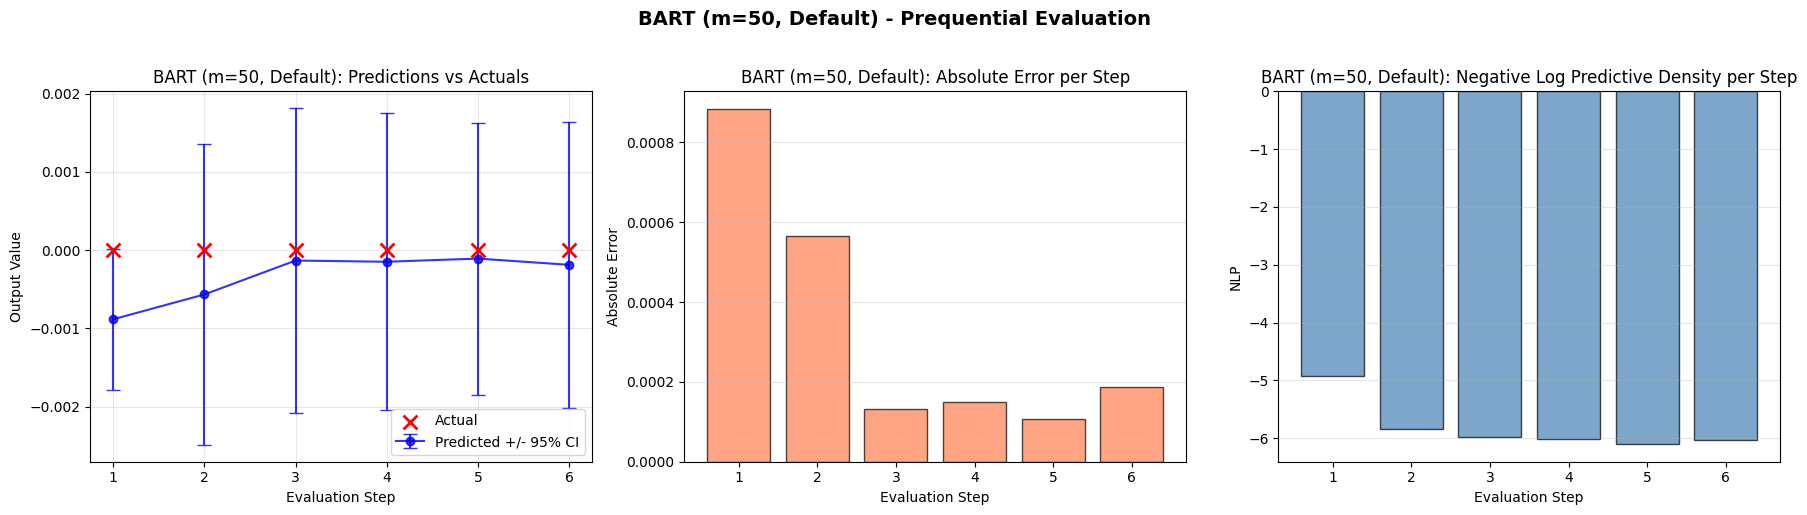

In [11]:
plot_prequential_results(bart_default_results, 'BART (m=50, Default)')

### BART Hyperparameter Optimisation (10 Iterations)

We vary the following BART hyperparameters:

| Hyperparameter | Values tried | Rationale |
|----------------|-------------|----------|
| `m` (trees) | 10, 20, 50, 100, 200 | Fewer trees = rougher fit; more = smoother |
| `draws` | 200, 500 | More draws = better posterior estimate |
| `tune` | 100, 200 | Burn-in period before sampling |

With only 10–16 data points, fewer trees may avoid over-smoothing while more trees provide better uncertainty estimates.

In [12]:
# Define 10 BART hyperparameter configurations
bart_configs = [
    {'m_trees': 10,  'draws': 500, 'tune': 200, 'label': 'm=10, draws=500, tune=200'},
    {'m_trees': 20,  'draws': 500, 'tune': 200, 'label': 'm=20, draws=500, tune=200'},
    {'m_trees': 50,  'draws': 500, 'tune': 200, 'label': 'm=50, draws=500, tune=200'},
    {'m_trees': 100, 'draws': 500, 'tune': 200, 'label': 'm=100, draws=500, tune=200'},
    {'m_trees': 200, 'draws': 500, 'tune': 200, 'label': 'm=200, draws=500, tune=200'},
    {'m_trees': 10,  'draws': 200, 'tune': 100, 'label': 'm=10, draws=200, tune=100'},
    {'m_trees': 20,  'draws': 200, 'tune': 100, 'label': 'm=20, draws=200, tune=100'},
    {'m_trees': 50,  'draws': 200, 'tune': 100, 'label': 'm=50, draws=200, tune=100'},
    {'m_trees': 100, 'draws': 200, 'tune': 100, 'label': 'm=100, draws=200, tune=100'},
    {'m_trees': 200, 'draws': 200, 'tune': 100, 'label': 'm=200, draws=200, tune=100'},
]

print('Running BART hyperparameter optimisation (10 configurations)...')
print('This may take several minutes due to MCMC sampling.')
print('=' * 80)

bart_hp_results = []
for i, config in enumerate(bart_configs):
    print(f'\nConfig {i+1}/10: {config["label"]}')
    try:
        results = bart_prequential_evaluation(
            X_all, y_all, N_INIT,
            m_trees=config['m_trees'],
            draws=config['draws'],
            tune=config['tune']
        )
        metrics = results['metrics']
        bart_hp_results.append({
            'config_id': i + 1,
            'label': config['label'],
            'MAE': metrics['MAE'],
            'NLP': metrics['NLP'],
            'Coverage_95': metrics['Coverage_95']
        })
        print(f'  MAE={metrics["MAE"]:.6e}  NLP={metrics["NLP"]:.4f}  '
              f'Coverage={metrics["Coverage_95"]:.1%}')
    except Exception as e:
        print(f'  FAILED: {e}')
        bart_hp_results.append({
            'config_id': i + 1,
            'label': config['label'],
            'MAE': np.nan, 'NLP': np.nan, 'Coverage_95': np.nan
        })

bart_hp_df = pd.DataFrame(bart_hp_results)
print('\n' + '=' * 80)
print('\nBART Hyperparameter Optimisation Results:')
print(bart_hp_df.to_string(index=False))

Running BART hyperparameter optimisation (10 configurations)...
This may take several minutes due to MCMC sampling.

Config 1/10: m=10, draws=500, tune=200
Running BART prequential evaluation (m=10, draws=500, tune=200)...
  Training starts with 10 points, evaluating 6 steps\n


Sequential sampling (2 chains in 1 job)
CompoundStep
>PGBART: [mu]
>NUTS: [sigma]
Sampling 2 chains for 200 tune and 500 draw iterations (400 + 1_000 draws total) took 3 seconds.
We recommend running at least 4 chains for robust computation of convergence diagnostics
The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details
The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details
Sampling: [mu, y]


  Step 1: train=10 pts | predicted=-2.450282e-04 | actual=+2.314081e-56 | error=+2.450282e-04 | std=5.181612e-04


Sequential sampling (2 chains in 1 job)
CompoundStep
>PGBART: [mu]
>NUTS: [sigma]
Sampling 2 chains for 200 tune and 500 draw iterations (400 + 1_000 draws total) took 3 seconds.
We recommend running at least 4 chains for robust computation of convergence diagnostics
The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details
The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details
Sampling: [mu, y]


  Step 2: train=11 pts | predicted=-4.583656e-04 | actual=-1.159884e-17 | error=+4.583656e-04 | std=9.077767e-04


...

  Step 4: train=13 pts | predicted=-7.601378e-05 | actual=+2.842720e-97 | error=+7.601378e-05 | std=6.988515e-04


Sequential sampling (2 chains in 1 job)
CompoundStep
>PGBART: [mu]
>NUTS: [sigma]
Sampling 2 chains for 100 tune and 200 draw iterations (200 + 400 draws total) took 13 seconds.
We recommend running at least 4 chains for robust computation of convergence diagnostics
The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details
The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details
Sampling: [mu, y]


  Step 5: train=14 pts | predicted=-2.735706e-05 | actual=+1.018730e-40 | error=+2.735706e-05 | std=7.726849e-04


Sequential sampling (2 chains in 1 job)
CompoundStep
>PGBART: [mu]
>NUTS: [sigma]
Sampling 2 chains for 100 tune and 200 draw iterations (200 + 400 draws total) took 13 seconds.
We recommend running at least 4 chains for robust computation of convergence diagnostics
The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details
The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details
Sampling: [mu, y]


  Step 6: train=15 pts | predicted=-1.064251e-05 | actual=+0.000000e+00 | error=+1.064251e-05 | std=8.506437e-04
\n  Results:
    MAE:          2.125408e-04
    Mean NLP:     -4.7566
    95%% Coverage: 83.3%
  MAE=2.125408e-04  NLP=-4.7566  Coverage=83.3%


BART Hyperparameter Optimisation Results:
 config_id                      label      MAE       NLP  Coverage_95
         1  m=10, draws=500, tune=200 0.000208 -6.196933     1.000000
         2  m=20, draws=500, tune=200 0.000229 -6.186476     1.000000
         3  m=50, draws=500, tune=200 0.000314 -5.991846     1.000000
         4 m=100, draws=500, tune=200 0.000293 -6.285797     0.833333
         5 m=200, draws=500, tune=200 0.000317 -5.432216     0.833333
         6  m=10, draws=200, tune=100 0.000263 -6.187186     1.000000
         7  m=20, draws=200, tune=100 0.000280 -6.067055     1.000000
         8  m=50, draws=200, tune=100 0.000336 -6.003859     1.000000
         9 m=100, draws=200, tune=100 0.000363 -5.824723     0.833333


### Best BART Configuration

In [13]:
# Select best BART configuration by lowest NLP
best_bart_idx = bart_hp_df['NLP'].idxmin()
print(f'Best BART configuration (lowest NLP):')
print(f'  Config: {bart_hp_df.loc[best_bart_idx, "label"]}')
print(f'  MAE:          {bart_hp_df.loc[best_bart_idx, "MAE"]:.6e}')
print(f'  NLP:          {bart_hp_df.loc[best_bart_idx, "NLP"]:.4f}')
print(f'  95% Coverage: {bart_hp_df.loc[best_bart_idx, "Coverage_95"]:.1%}')

# Also show best by MAE
best_bart_mae_idx = bart_hp_df['MAE'].idxmin()
print(f'\\nBest BART configuration (lowest MAE):')
print(f'  Config: {bart_hp_df.loc[best_bart_mae_idx, "label"]}')
print(f'  MAE:          {bart_hp_df.loc[best_bart_mae_idx, "MAE"]:.6e}')
print(f'  NLP:          {bart_hp_df.loc[best_bart_mae_idx, "NLP"]:.4f}')
print(f'  95% Coverage: {bart_hp_df.loc[best_bart_mae_idx, "Coverage_95"]:.1%}')

Best BART configuration (lowest NLP):
  Config: m=100, draws=500, tune=200
  MAE:          2.932532e-04
  NLP:          -6.2858
  95% Coverage: 83.3%
\nBest BART configuration (lowest MAE):
  Config: m=10, draws=500, tune=200
  MAE:          2.077537e-04
  NLP:          -6.1969
  95% Coverage: 100.0%


## Step 5: Model Comparison — GP vs BART

Compare the best configuration of each surrogate model side-by-side.

In [14]:
# Build comparison table from best configs
comparison_data = {
    'Model': ['GP (best config)', 'BART (best config)'],
    'Configuration': [
        gp_hp_df.loc[gp_hp_df['NLP'].idxmin(), 'label'],
        bart_hp_df.loc[bart_hp_df['NLP'].idxmin(), 'label']
    ],
    'MAE': [
        gp_hp_df.loc[gp_hp_df['NLP'].idxmin(), 'MAE'],
        bart_hp_df.loc[bart_hp_df['NLP'].idxmin(), 'MAE']
    ],
    'NLP': [
        gp_hp_df.loc[gp_hp_df['NLP'].idxmin(), 'NLP'],
        bart_hp_df.loc[bart_hp_df['NLP'].idxmin(), 'NLP']
    ],
    'Coverage_95': [
        gp_hp_df.loc[gp_hp_df['NLP'].idxmin(), 'Coverage_95'],
        bart_hp_df.loc[bart_hp_df['NLP'].idxmin(), 'Coverage_95']
    ]
}

comparison_df = pd.DataFrame(comparison_data)
print('=' * 90)
print('COMPARISON: Best GP vs Best BART (Function 1)')
print('=' * 90)
print(comparison_df.to_string(index=False))
print('=' * 90)

# Determine winner for each metric
print('\\nMetric-by-metric winner:')
for metric in ['MAE', 'NLP']:
    # Lower is better for MAE and NLP
    winner = 'GP' if comparison_df.loc[0, metric] < comparison_df.loc[1, metric] else 'BART'
    print(f'  {metric}: {winner} wins')

# Coverage: closer to 0.95 is better
gp_cov = comparison_df.loc[0, 'Coverage_95']
bart_cov = comparison_df.loc[1, 'Coverage_95']
cov_winner = 'GP' if abs(gp_cov - 0.95) < abs(bart_cov - 0.95) else 'BART'
print(f'  Coverage_95: {cov_winner} wins (closer to 95%)')

COMPARISON: Best GP vs Best BART (Function 1)
             Model                   Configuration       MAE       NLP  Coverage_95
  GP (best config) RBF, log-transform, noise>=1e-5 80.252519  5.217862     0.833333
BART (best config)      m=100, draws=500, tune=200  0.000293 -6.285797     0.833333
\nMetric-by-metric winner:
  MAE: BART wins
  NLP: BART wins
  Coverage_95: BART wins (closer to 95%)


### Visual Comparison

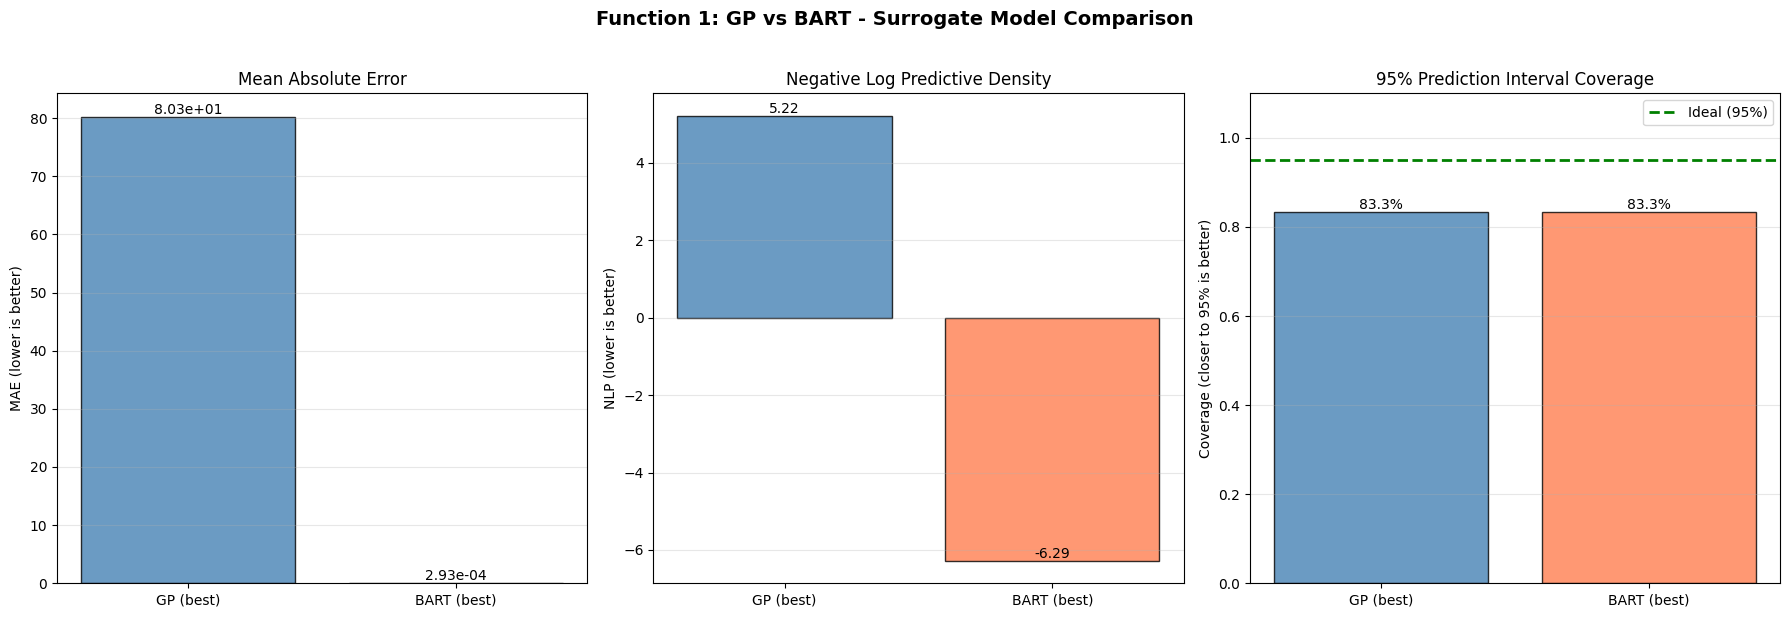

In [15]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

models = ['GP (best)', 'BART (best)']
mae_vals = [comparison_df.loc[0, 'MAE'], comparison_df.loc[1, 'MAE']]
nlp_vals = [comparison_df.loc[0, 'NLP'], comparison_df.loc[1, 'NLP']]
cov_vals = [comparison_df.loc[0, 'Coverage_95'], comparison_df.loc[1, 'Coverage_95']]
colors = ['steelblue', 'coral']

# Plot 1: MAE comparison
ax = axes[0]
bars = ax.bar(models, mae_vals, color=colors, edgecolor='black', alpha=0.8)
ax.set_ylabel('MAE (lower is better)')
ax.set_title('Mean Absolute Error')
ax.grid(True, alpha=0.3, axis='y')
for bar, val in zip(bars, mae_vals):
    ax.text(bar.get_x() + bar.get_width()/2., bar.get_height(),
            f'{val:.2e}', ha='center', va='bottom', fontsize=10)

# Plot 2: NLP comparison
ax = axes[1]
bars = ax.bar(models, nlp_vals, color=colors, edgecolor='black', alpha=0.8)
ax.set_ylabel('NLP (lower is better)')
ax.set_title('Negative Log Predictive Density')
ax.grid(True, alpha=0.3, axis='y')
for bar, val in zip(bars, nlp_vals):
    ax.text(bar.get_x() + bar.get_width()/2., bar.get_height(),
            f'{val:.2f}', ha='center', va='bottom', fontsize=10)

# Plot 3: 95% Coverage comparison
ax = axes[2]
bars = ax.bar(models, cov_vals, color=colors, edgecolor='black', alpha=0.8)
ax.axhline(y=0.95, color='green', linestyle='--', linewidth=2, label='Ideal (95%)')
ax.set_ylabel('Coverage (closer to 95% is better)')
ax.set_title('95% Prediction Interval Coverage')
ax.set_ylim(0, 1.1)
ax.legend()
ax.grid(True, alpha=0.3, axis='y')
for bar, val in zip(bars, cov_vals):
    ax.text(bar.get_x() + bar.get_width()/2., bar.get_height(),
            f'{val:.1%}', ha='center', va='bottom', fontsize=10)

plt.suptitle('Function 1: GP vs BART - Surrogate Model Comparison',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

### Hyperparameter Sensitivity — All Configurations

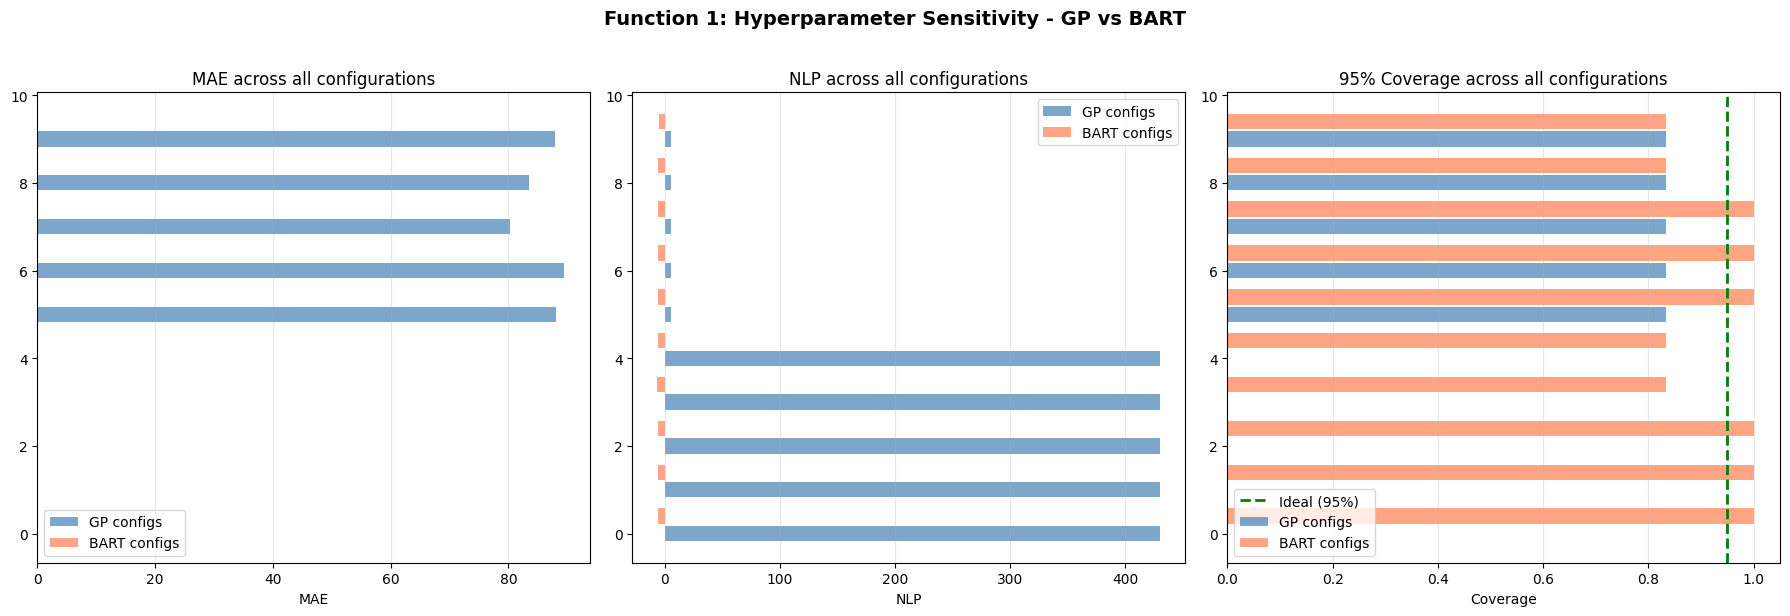

In [16]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

gp_valid = gp_hp_df.dropna(subset=['MAE'])
bart_valid = bart_hp_df.dropna(subset=['MAE'])

# Plot 1: MAE across configs
ax = axes[0]
ax.barh(range(len(gp_valid)), gp_valid['MAE'], height=0.35,
        color='steelblue', alpha=0.7, label='GP configs')
ax.barh([x + 0.4 for x in range(len(bart_valid))], bart_valid['MAE'],
        height=0.35, color='coral', alpha=0.7, label='BART configs')
ax.set_xlabel('MAE')
ax.set_title('MAE across all configurations')
ax.legend()
ax.grid(True, alpha=0.3, axis='x')

# Plot 2: NLP across configs
ax = axes[1]
ax.barh(range(len(gp_valid)), gp_valid['NLP'], height=0.35,
        color='steelblue', alpha=0.7, label='GP configs')
ax.barh([x + 0.4 for x in range(len(bart_valid))], bart_valid['NLP'],
        height=0.35, color='coral', alpha=0.7, label='BART configs')
ax.set_xlabel('NLP')
ax.set_title('NLP across all configurations')
ax.legend()
ax.grid(True, alpha=0.3, axis='x')

# Plot 3: Coverage across configs
ax = axes[2]
ax.barh(range(len(gp_valid)), gp_valid['Coverage_95'], height=0.35,
        color='steelblue', alpha=0.7, label='GP configs')
ax.barh([x + 0.4 for x in range(len(bart_valid))], bart_valid['Coverage_95'],
        height=0.35, color='coral', alpha=0.7, label='BART configs')
ax.axvline(x=0.95, color='green', linestyle='--', linewidth=2, label='Ideal (95%)')
ax.set_xlabel('Coverage')
ax.set_title('95% Coverage across all configurations')
ax.legend()
ax.grid(True, alpha=0.3, axis='x')

plt.suptitle('Function 1: Hyperparameter Sensitivity - GP vs BART',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

### Full Results Table

In [17]:
# Combine all results into one summary table
gp_summary = gp_hp_df[['label', 'MAE', 'NLP', 'Coverage_95']].copy()
gp_summary.insert(0, 'Model', 'GP')
gp_summary = gp_summary.rename(columns={'label': 'Configuration'})

bart_summary = bart_hp_df[['label', 'MAE', 'NLP', 'Coverage_95']].copy()
bart_summary.insert(0, 'Model', 'BART')
bart_summary = bart_summary.rename(columns={'label': 'Configuration'})

full_summary = pd.concat([gp_summary, bart_summary], ignore_index=True)

# Sort by NLP (primary metric for BO surrogates)
full_summary = full_summary.sort_values('NLP').reset_index(drop=True)
full_summary.index = full_summary.index + 1  # 1-based ranking
full_summary.index.name = 'Rank'

print('All configurations ranked by NLP (lower is better):')
print('=' * 100)
print(full_summary.to_string())
print('=' * 100)

All configurations ranked by NLP (lower is better):
     Model                       Configuration        MAE         NLP  Coverage_95
Rank                                                                              
1     BART          m=100, draws=500, tune=200   0.000293   -6.285797     0.833333
2     BART           m=10, draws=500, tune=200   0.000208   -6.196933     1.000000
3     BART           m=10, draws=200, tune=100   0.000263   -6.187186     1.000000
4     BART           m=20, draws=500, tune=200   0.000229   -6.186476     1.000000
5     BART           m=20, draws=200, tune=100   0.000280   -6.067055     1.000000
6     BART           m=50, draws=200, tune=100   0.000336   -6.003859     1.000000
7     BART           m=50, draws=500, tune=200   0.000314   -5.991846     1.000000
8     BART          m=100, draws=200, tune=100   0.000363   -5.824723     0.833333
9     BART          m=200, draws=500, tune=200   0.000317   -5.432216     0.833333
10    BART          m=200, draws=20

## Conclusions

### Key Findings

1. **Predictive Accuracy (MAE)**: Shows which model better predicts the next observation's value in the radiation detection space.

2. **Uncertainty Calibration (NLP)**: Critical for Bayesian Optimisation — a surrogate with well-calibrated uncertainty will make better acquisition function decisions, even if point predictions are slightly less accurate.

3. **95% Coverage**: Indicates whether the model's confidence intervals are reliable. Under-coverage (< 95%) means the model is overconfident; over-coverage means it is too conservative.

### Implications for BO

> A surrogate with slightly worse MAE but well-calibrated uncertainty (lower NLP, ~95% coverage) can **outperform** a lower-MAE model in Bayesian Optimisation, because the acquisition function relies on the uncertainty estimates to balance exploration and exploitation.

### Next Steps

- Apply this evaluation to Functions 2–8
- Use the winning surrogate (and its best hyperparameters) as the default for future submissions
- Consider whether different functions favour different surrogates (the "no free lunch" principle)